In [ ]:
import pandas as pd
from pathlib import Path

src_dir = Path.cwd()
pfas_csvs = list((Path.cwd() / "pfas_csvs").glob("*.csv"))


dfs = []
for path in pfas_csvs:
    df = pd.read_csv(path)
    print(path)
    print(df.shape)
    dfs.append(df)

pfas_df = pd.concat(dfs, ignore_index=True)
print(pfas_df.shape)

In [1]:
import pandas as pd

df = pd.read_csv("./france_pfas_combined.csv")

Sorting from City name and coordinate

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_missing = df[df["city"].isna()].copy()

#Rumilly coord
lat, lon = 45.8667, 5.9333
# radius_deg = 0.1  # ~11 km
radius_deg = 0.04  # ~3.k km

df_treatment_coord = df[
    (df["lat"].between(lat - radius_deg, lat + radius_deg)) &
    (df["lon"].between(lon - radius_deg, lon + radius_deg))
].copy()


treat_city = ['RUMILLY', 'Rumilly']
df_treatment_name = df[df["city"].isin(treat_city) & (df["lat"].isna())].copy()

df_treatment = pd.concat([df_treatment_name, df_treatment_coord],ignore_index=True).drop_duplicates()
df_treatment["date"] = pd.to_datetime(df_treatment["date"], errors="coerce")
df_treatment["quarter"] = df_treatment["date"].dt.to_period("Q")

zero_count = (df_treatment["pfas_sum"] == 0).sum()
print(zero_count)
print(df_treatment.shape)

88
(209, 22)


Due to uneven number of sample per years, average will be calculated

In [36]:
def robust_stats(x, trim=0.10):
    x = pd.Series(x).dropna().astype(float)
    if len(x) == 0:
        return pd.Series({
            "median": np.nan,
            "trimmed_mean": np.nan,
            "log_mean": np.nan,
            "variance": np.nan,
            "std_dev": np.nan,
            "n_obs": 0
        })

    med = x.median()

    lo, hi = x.quantile(trim), x.quantile(1 - trim)
    xt = x[(x >= lo) & (x <= hi)]
    tmean = xt.mean() if len(xt) else np.nan

    lmean = np.expm1(np.log1p(x).mean())

    variance = x.var(ddof=1)
    std_dev = x.std(ddof=1)

    return pd.Series({
        "median": med,
        "trimmed_mean": tmean,
        "log_mean": lmean,
        "variance": variance,
        "std_dev": std_dev,
        "n_obs": len(x)
    })


# --- IQR outlier filter per year ---
def iqr_filter(group):
    q1 = group["pfas_sum"].quantile(0.25)
    q3 = group["pfas_sum"].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return group[(group["pfas_sum"] >= lower) & (group["pfas_sum"] <= upper)]

In [37]:
value_col = "pfas_sum"   
d = df_treatment.copy()

d = d[d["date"] >= pd.Timestamp("2019-01-01")]
d[value_col] = pd.to_numeric(d[value_col], errors="coerce")
d = d.dropna(subset=[value_col])

In [ ]:
year_robust = (
    d.groupby("year")[value_col]
     .
     apply(robust_stats)
     .unstack()
     .reset_index()
)

quarter_robust = (
    d.groupby("quarter")[value_col]
     .apply(robust_stats)
     .unstack()
     .reset_index()
)

display(year_robust)
display(quarter_robust)

,year,median,trimmed_mean,log_mean,variance,std_dev,n_obs
0,2019,91.90,61.266667,13.557174,15673.343333,125.193224,4.0
1,2020,0.00,33.775000,6.709408,8888.723000,94.280024,5.0
2,2021,68.10,45.400000,11.062297,7032.922500,83.862521,4.0
3,2022,107.25,102.275000,48.703054,5162.385682,71.849744,12.0
4,2023,18.00,31.144615,10.203563,9663.241328,98.301787,73.0
5,2024,19.80,37.070455,11.381205,5891.645765,76.757057,49.0
6,2025,63.60,69.130769,40.798922,5092.753842,71.363533,29.0


,quarter,median,trimmed_mean,log_mean,variance,std_dev,n_obs
0,2019Q1,0.00,0.000000,0.000000,NaN,NaN,1.0
1,2019Q2,91.90,NaN,12.594116,16891.220000,129.966226,2.0
2,2019Q4,242.00,242.000000,242.000000,NaN,NaN,1.0
3,2020Q2,99.55,NaN,13.145671,19820.405000,140.784960,2.0
4,2020Q3,0.00,0.000000,0.000000,NaN,NaN,1.0
5,2020Q4,67.55,NaN,10.666190,9126.005000,95.530126,2.0
6,2021Q2,76.65,NaN,11.421755,11750.445000,108.399470,2.0
7,2021Q3,0.00,0.000000,0.000000,NaN,NaN,1.0
8,2021Q4,136.20,136.200000,136.200000,NaN,NaN,1.0
9,2022Q1,0.00,0.000000,0.000000,NaN,NaN,1.0


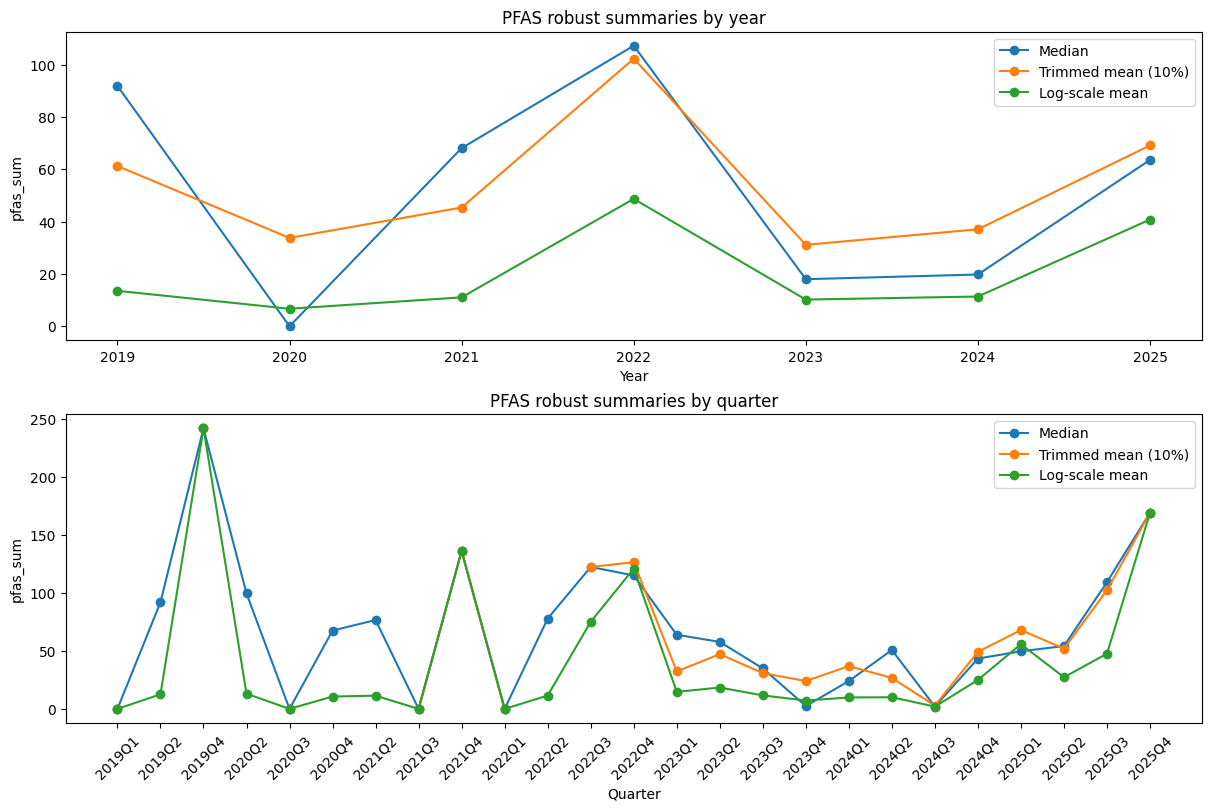

In [39]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)

# Year plot
axes[0].plot(year_robust["year"], year_robust["median"], marker="o", label="Median")
axes[0].plot(year_robust["year"], year_robust["trimmed_mean"], marker="o", label="Trimmed mean (10%)")
axes[0].plot(year_robust["year"], year_robust["log_mean"], marker="o", label="Log-scale mean")
axes[0].set_title("PFAS robust summaries by year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel(value_col)
axes[0].legend()

# Quarter plot
q_labels = quarter_robust["quarter"].astype(str)
axes[1].plot(q_labels, quarter_robust["median"], marker="o", label="Median")
axes[1].plot(q_labels, quarter_robust["trimmed_mean"], marker="o", label="Trimmed mean (10%)")
axes[1].plot(q_labels, quarter_robust["log_mean"], marker="o", label="Log-scale mean")
axes[1].set_title("PFAS robust summaries by quarter")
axes[1].set_xlabel("Quarter")
axes[1].set_ylabel(value_col)
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.show()

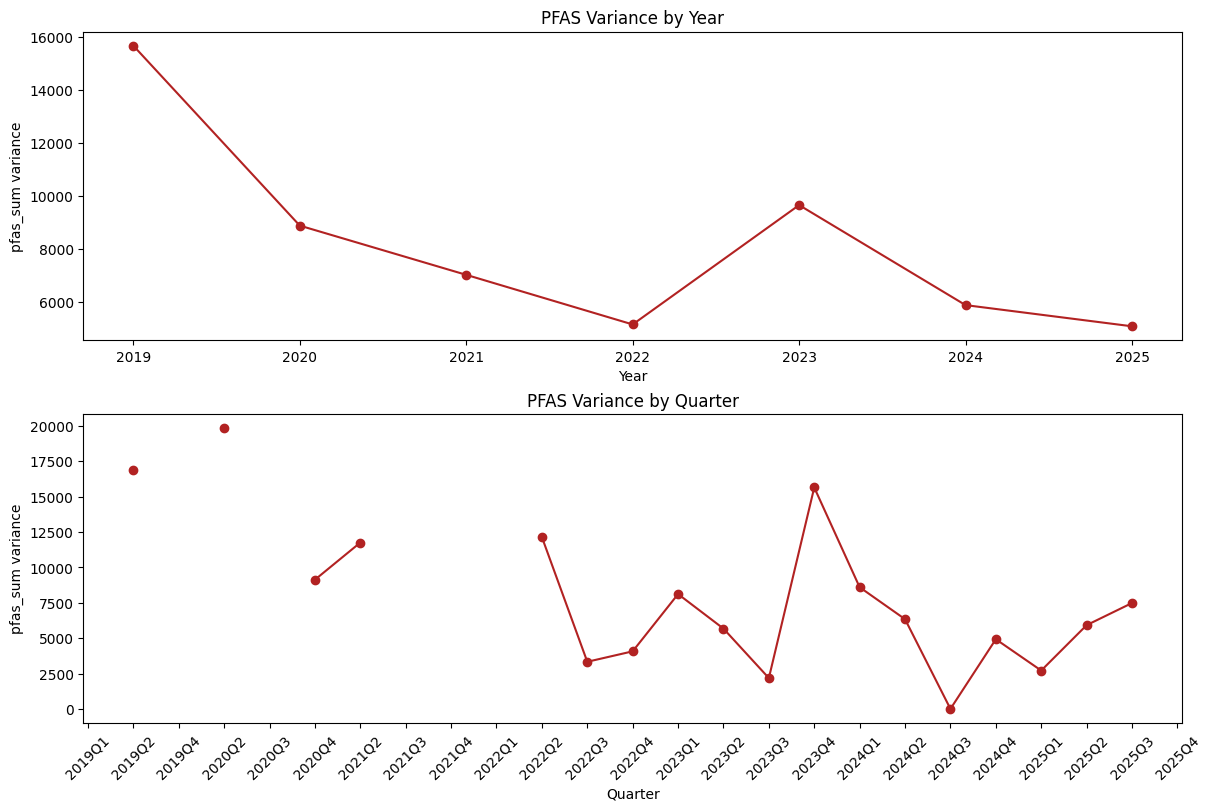

In [40]:
# ---- variance plot ----
fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)

# Year variance
axes[0].plot(year_robust["year"], year_robust["variance"], marker="o", color="firebrick")
axes[0].set_title("PFAS Variance by Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel(f"{value_col} variance")

# Quarter variance
q_labels = quarter_robust["quarter"].astype(str)
axes[1].plot(q_labels, quarter_robust["variance"], marker="o", color="firebrick")
axes[1].set_title("PFAS Variance by Quarter")
axes[1].set_xlabel("Quarter")
axes[1].set_ylabel(f"{value_col} variance")
axes[1].tick_params(axis="x", rotation=45)

plt.show()

/var/folders/c2/nw3f3w191x147lw_j8x81st80000gn/T/ipykernel_68560/1491782228.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  plot_df_clean = plot_df.groupby("year", group_keys=False).apply(iqr_filter)
/var/folders/c2/nw3f3w191x147lw_j8x81st80000gn/T/ipykernel_68560/1491782228.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


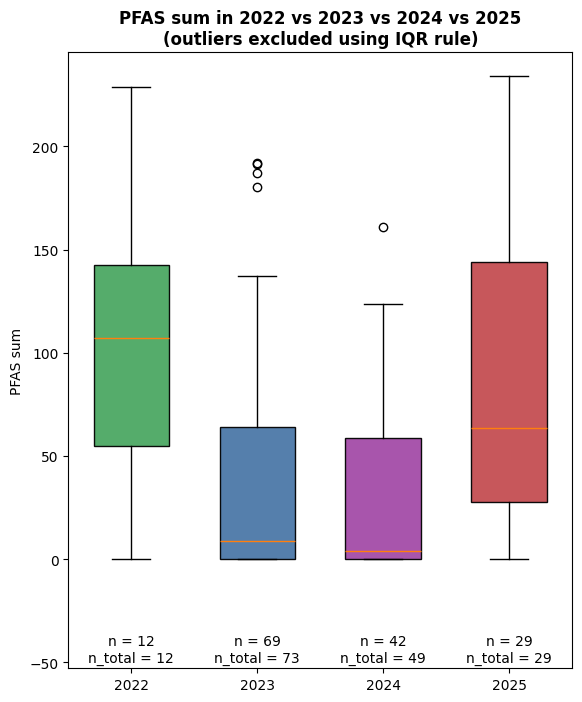

In [41]:
plot_df = d[d["year"].isin([2022, 2023, 2024, 2025])][["year", value_col]].copy()
n_tots= [(plot_df["year"] == 2022).sum(), (plot_df["year"] == 2023).sum(), (plot_df["year"] == 2024).sum(), (plot_df["year"] == 2025).sum()]

plot_df_clean = plot_df.groupby("year", group_keys=False).apply(iqr_filter)

y2022 = plot_df_clean.loc[plot_df_clean["year"] == 2022, value_col].values
y2023 = plot_df_clean.loc[plot_df_clean["year"] == 2023, value_col].values
y2024 = plot_df_clean.loc[plot_df_clean["year"] == 2024, value_col].values
y2025 = plot_df_clean.loc[plot_df_clean["year"] == 2025, value_col].values


if len(y2022) == 0 or len(y2023) == 0 or len(y2024) == 0 or len(y2025) == 0:
    print("One of the years has no observations after filtering.")
else:
    fig, ax = plt.subplots(figsize=(6.5, 8))

    bp = ax.boxplot(
        [y2022, y2023, y2024, y2025],
        labels=["2022", "2023", "2024", "2025"],
        patch_artist=True,
        widths=0.6
    )

    # colors similar to your example style
    colors = ["#4CA863","#4C78A8", "#A34CA8", "#C44E52"]
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.95)

    ax.set_title("PFAS sum in 2022 vs 2023 vs 2024 vs 2025\n(outliers excluded using IQR rule)", weight="bold")
    ax.set_ylabel("PFAS sum")

    # add sample sizes under x labels
    n_vals = [len(y2022), len(y2023), len(y2024), len(y2025)]
    ymin, ymax = ax.get_ylim()
    offset = 0.08 * (ymax - ymin)
    ax.set_ylim(ymin - 2 * offset, ymax)
    for i, (n_obs, n_tot) in enumerate(zip(n_vals, n_tots), start=1):
        ax.text(i, ymin - 1.2 * offset, f"n = {n_obs}", ha="center", va="top")
        ax.text(i, ymin - 1.6 * offset, f"n_total = {n_tot}", ha="center", va="top")
    plt.show()